In [1]:
import pandas as pd 
import numpy as np

In [2]:
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_validate
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier 

In [3]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix
)

In [4]:
pip install imblearn

Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.


In [5]:
from imblearn.over_sampling import SMOTE
from imblearn.under_sampling import TomekLinks

In [6]:
import matplotlib.pyplot as plt
import seaborn as sns

In [7]:
path =r"C:\Users\Hp\Downloads\Edukron\KNN\data\application_train.csv"
df=pd.read_csv(path)
print(df.shape)

(307511, 122)


In [8]:
df.head()

,SK_ID_CURR,TARGET,NAME_CONTRACT_TYPE,CODE_GENDER,FLAG_OWN_CAR,FLAG_OWN_REALTY,CNT_CHILDREN,AMT_INCOME_TOTAL,AMT_CREDIT,AMT_ANNUITY,...,FLAG_DOCUMENT_18,FLAG_DOCUMENT_19,FLAG_DOCUMENT_20,FLAG_DOCUMENT_21,AMT_REQ_CREDIT_BUREAU_HOUR,AMT_REQ_CREDIT_BUREAU_DAY,AMT_REQ_CREDIT_BUREAU_WEEK,AMT_REQ_CREDIT_BUREAU_MON,AMT_REQ_CREDIT_BUREAU_QRT,AMT_REQ_CREDIT_BUREAU_YEAR
0,100002,1,Cash loans,M,N,Y,0,202500.0,406597.5,24700.5,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,1.0
1,100003,0,Cash loans,F,N,N,0,270000.0,1293502.5,35698.5,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0
2,100004,0,Revolving loans,M,Y,Y,0,67500.0,135000.0,6750.0,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0
3,100006,0,Cash loans,F,N,Y,0,135000.0,312682.5,29686.5,...,0,0,0,0,NaN,NaN,NaN,NaN,NaN,NaN
4,100007,0,Cash loans,M,N,Y,0,121500.0,513000.0,21865.5,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0


In [9]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 307511 entries, 0 to 307510
Columns: 122 entries, SK_ID_CURR to AMT_REQ_CREDIT_BUREAU_YEAR
dtypes: float64(65), int64(41), object(16)
memory usage: 286.2+ MB


In [10]:
df.describe()

,SK_ID_CURR,TARGET,CNT_CHILDREN,AMT_INCOME_TOTAL,AMT_CREDIT,AMT_ANNUITY,AMT_GOODS_PRICE,REGION_POPULATION_RELATIVE,DAYS_BIRTH,DAYS_EMPLOYED,...,FLAG_DOCUMENT_18,FLAG_DOCUMENT_19,FLAG_DOCUMENT_20,FLAG_DOCUMENT_21,AMT_REQ_CREDIT_BUREAU_HOUR,AMT_REQ_CREDIT_BUREAU_DAY,AMT_REQ_CREDIT_BUREAU_WEEK,AMT_REQ_CREDIT_BUREAU_MON,AMT_REQ_CREDIT_BUREAU_QRT,AMT_REQ_CREDIT_BUREAU_YEAR
count,307511.000000,307511.000000,307511.000000,3.075110e+05,3.075110e+05,307499.000000,3.072330e+05,307511.000000,307511.000000,307511.000000,...,307511.000000,307511.000000,307511.000000,307511.000000,265992.000000,265992.000000,265992.000000,265992.000000,265992.000000,265992.000000
mean,278180.518577,0.080729,0.417052,1.687979e+05,5.990260e+05,27108.573909,5.383962e+05,0.020868,-16036.995067,63815.045904,...,0.008130,0.000595,0.000507,0.000335,0.006402,0.007000,0.034362,0.267395,0.265474,1.899974
std,102790.175348,0.272419,0.722121,2.371231e+05,4.024908e+05,14493.737315,3.694465e+05,0.013831,4363.988632,141275.766519,...,0.089798,0.024387,0.022518,0.018299,0.083849,0.110757,0.204685,0.916002,0.794056,1.869295
min,100002.000000,0.000000,0.000000,2.565000e+04,4.500000e+04,1615.500000,4.050000e+04,0.000290,-25229.000000,-17912.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,189145.500000,0.000000,0.000000,1.125000e+05,2.700000e+05,16524.000000,2.385000e+05,0.010006,-19682.000000,-2760.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,278202.000000,0.000000,0.000000,1.471500e+05,5.135310e+05,24903.000000,4.500000e+05,0.018850,-15750.000000,-1213.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000
75%,367142.500000,0.000000,1.000000,2.025000e+05,8.086500e+05,34596.000000,6.795000e+05,0.028663,-12413.000000,-289.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,3.000000
max,456255.000000,1.000000,19.000000,1.170000e+08,4.050000e+06,258025.500000,4.050000e+06,0.072508,-7489.000000,365243.000000,...,1.000000,1.000000,1.000000,1.000000,4.000000,9.000000,8.000000,27.000000,261.000000,25.000000


In [11]:
print(df["TARGET"].value_counts())

TARGET
0    282686
1     24825
Name: count, dtype: int64


In [12]:
print(df["TARGET"].value_counts(normalize=True)*100)

TARGET
0    91.927118
1     8.072882
Name: proportion, dtype: float64


In [13]:
X=df.drop("TARGET",axis=1)
y=df["TARGET"]

print("Features",X.shape)
print("Target",y.shape)

Features (307511, 121)
Target (307511,)


In [14]:
if "SK_ID_CURR" in X.columns:
    X=X.drop("SK_ID_CURR",axis=1)
print(X.shape)

(307511, 120)


In [15]:
categorical_columns=X.select_dtypes(
    include=["object"]
).columns

numerical_columns=X.select_dtypes(
    exclude=["object"]
).columns

print("Categorical Columns:",len(categorical_columns))
print("Numerical Columns:",len(numerical_columns))

Categorical Columns: 16
Numerical Columns: 104


In [16]:
X=pd.get_dummies(
    X,
    columns=categorical_columns,
    drop_first=True
)

print("Shape After Encoding:",X.shape)

Shape After Encoding: (307511, 228)


In [17]:
X=X.replace(
    [np.inf,-np.inf],
    np.nan
)

In [18]:
X_train,X_test,y_train,y_test=train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

In [19]:
print("X_train:",X_train.shape)
print("X_test:",X_test.shape)
print("y_train:",y_train.value_counts())
print("y_test:",y_test.value_counts())

X_train: (246008, 228)
X_test: (61503, 228)
y_train: TARGET
0    226148
1     19860
Name: count, dtype: int64
y_test: TARGET
0    56538
1     4965
Name: count, dtype: int64


In [20]:
imputer=SimpleImputer(strategy="median")
X_train=imputer.fit_transform(X_train)
X_test=imputer.transform(X_test)

In [21]:
scaler=StandardScaler()
X_train=scaler.fit_transform(X_train)
X_test=scaler.transform(X_test)

In [22]:
print("Before SMOTE:",pd.Series(y_train).value_counts())

Before SMOTE: TARGET
0    226148
1     19860
Name: count, dtype: int64


In [23]:
smote=SMOTE(
    random_state=42
)

X_train_smote,y_train_smote=smote.fit_resample(
    X_train,
    y_train
)

print("After SMOTE:",pd.Series(y_train_smote).value_counts())

After SMOTE: TARGET
0    226148
1    226148
Name: count, dtype: int64


In [24]:
tomek=TomekLinks()

X_train_clean,y_train_clean=tomek.fit_resample(
    X_train_smote,
    y_train_smote
)

print("After Tomek Links:",pd.Series(y_train_clean).value_counts())

print("Final training shape:",X_train_clean.shape)

After Tomek Links: TARGET
0    226148
1    226143
Name: count, dtype: int64
Final training shape: (452291, 228)


In [25]:
knn=KNeighborsClassifier(
    n_neighbors=5,
    metric="minkowski",
    p=2
)

In [26]:
knn.fit(
    X_train_clean,
    y_train_clean
)

,n_neighbors,5
,weights,'uniform'
,algorithm,'auto'
,leaf_size,30
,p,2
,metric,'minkowski'
,metric_params,None
,n_jobs,None


In [27]:
y_pred=knn.predict(X_test)

In [28]:
accuracy=accuracy_score(
    y_test,
    y_pred
)

print("Accuracy:",accuracy)

Accuracy: 0.5815651269043787


In [35]:
precision=precision_score(
    y_test,
    y_pred,
    zero_division=0
)
print("Precision:",precision)

Precision: 0.10474233082134429


In [29]:
recall=recall_score(
    y_test,
    y_pred,
    zero_division=0
)
print("Recall:",recall)

Recall: 0.5542799597180262


In [30]:
f1=f1_score(
    y_test,
    y_pred,
    zero_division=0
)

print("F1 Score:",f1)

F1 Score: 0.1761900188866481


In [31]:
print(
    classification_report(
        y_test,
        y_pred,
        zero_division=0
    )
)

              precision    recall  f1-score   support

           0       0.94      0.58      0.72     56538
           1       0.10      0.55      0.18      4965

    accuracy                           0.58     61503
   macro avg       0.52      0.57      0.45     61503
weighted avg       0.87      0.58      0.68     61503



In [32]:
cm=confusion_matrix(
    y_test,
    y_pred
)

print(cm)

[[33016 23522]
 [ 2213  2752]]


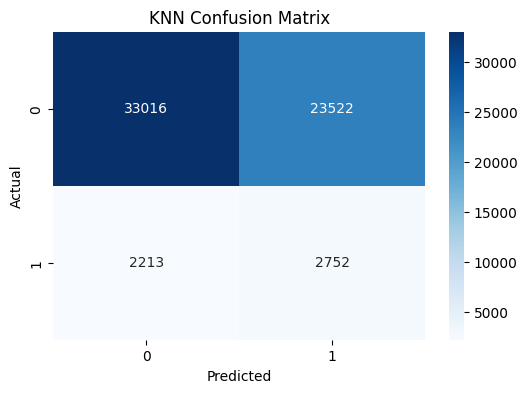

In [33]:
plt.figure(figsize=(6, 4))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues"
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("KNN Confusion Matrix")

plt.show()

In [36]:
results = pd.DataFrame({
    "Metric": [
        "Accuracy",
        "Precision",
        "Recall",
        "F1 Score"
    ],
    "Score": [
        accuracy,
        precision,
        recall,
        f1
    ]
})

results

,Metric,Score
0,Accuracy,0.581565
1,Precision,0.104742
2,Recall,0.554280
3,F1 Score,0.176190


In [37]:
skf = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

In [38]:
scoring = {
    "accuracy": "accuracy",
    "precision": "precision",
    "recall": "recall",
    "f1": "f1"
}

In [39]:
cv_results = cross_validate(
    knn,
    X_train_clean,
    y_train_clean,
    cv=skf,
    scoring=scoring
)

In [40]:
print(
    "5-Fold Cross Validation Results"
)

print(
    "Mean Accuracy :",
    cv_results["test_accuracy"].mean()
)

print(
    "Mean Precision:",
    cv_results["test_precision"].mean()
)

print(
    "Mean Recall   :",
    cv_results["test_recall"].mean()
)

print(
    "Mean F1 Score :",
    cv_results["test_f1"].mean()
)

5-Fold Cross Validation Results
Mean Accuracy : 0.7733162916484921
Mean Precision: 0.6881953250017039
Mean Recall   : 0.99946051812943
Mean F1 Score : 0.8151233837859955
